# E.R.M.E.S. - Fase 2: Data Engineering e Pre-Processing

Alla luce delle criticità identificate durante la fase di *Exploratory Data Analysis* (EDA), in questo notebook ingegnerizziamo la pipeline dei dati (ETL: Extract, Transform, Load) che alimenterà la Rete Neurale.

Le operazioni implementate traducono i requisiti teorici in soluzioni architetturali:
1. **I/O Optimization:** Utilizzo delle API `tf.data` per caricare le immagini in modo asincrono, applicando `cache()` e `prefetch()` per evitare la "fame di dati" (Data Starvation) della GPU.
2. **Riduzione Dimensionale Nativa:** Forzatura della lettura a singolo canale (Grayscale) per eliminare la ridondanza dei layer RGB.
3. **Data Augmentation:** Iniezione di perturbazioni spaziali controllate (traslazioni, zoom, rotazioni) per indurre generalizzazione e combattere il disallineamento geometrico dei volti.
4. **Cost-Sensitive Learning:** Calcolo matematico dei *class weights* per penalizzare dinamicamente gli errori sulla classe minoritaria (Disgust) e arginare il bias della classe maggioritaria (Happy).

In [1]:
"""
Modulo di configurazione globale.
Importa i framework per l'ingegnerizzazione dei tensori (TensorFlow), 
il calcolo vettoriale e imposta lo stile grafico del progetto.
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from typing import Tuple, Dict, List, Any
import logging

# Silenziamo i warning non critici di TensorFlow per pulire l'output
tf.get_logger().setLevel(logging.ERROR)

# Configurazione stile grafico
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

print("--- INIZIALIZZAZIONE DATA ENGINEERING ---")
print(f"TensorFlow version: {tf.__version__}")

--- INIZIALIZZAZIONE DATA ENGINEERING ---
TensorFlow version: 2.10.1


## 2.1 Ingestion e Ottimizzazione I/O
Il caricamento in memoria di decine di migliaia di immagini può generare un severo collo di bottiglia. 
Tramite le direttive `tf.data.AUTOTUNE`, deleghiamo al processore (CPU) il compito di calcolare dinamicamente quanti thread allocare per leggere i file dal disco, mantenendo la memoria della GPU sempre piena e pronta per la *backpropagation*.

In [2]:
# Percorsi di root del dataset
train_dir = Path('../data/fer2013/train')
test_dir = Path('../data/fer2013/test')

# Iperparametri della pipeline spaziale
BATCH_SIZE = 64
IMG_SIZE = (48, 48)

def create_datasets() -> Tuple[tf.data.Dataset, tf.data.Dataset]:
    """
    Inizializza le pipeline tf.data per i set di addestramento e validazione.
    Converte le immagini in scala di grigi e applica l'ottimizzazione I/O.
    
    Returns:
        Tuple[tf.data.Dataset, tf.data.Dataset]: Stream iterabili di tensori (X, y).
    """
    print("Inizializzazione Training Stream...")
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        color_mode='grayscale', # Risolve la ridondanza RGB
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,           # Essenziale per la stocasticità del gradiente
        label_mode='int'        # Etichette codificate come interi (0-6)
    )

    print("\nInizializzazione Validation Stream...")
    val_dataset = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        color_mode='grayscale',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,          # Non mescolare il set di test
        label_mode='int'
    )

    # Cache in RAM e Prefetching Asincrono
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
    val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
    
    return train_dataset, val_dataset

train_ds, val_ds = create_datasets()

Inizializzazione Training Stream...
Found 28709 files belonging to 7 classes.

Inizializzazione Validation Stream...
Found 7178 files belonging to 7 classes.


## 2.2 Pipeline di Data Augmentation e Normalizzazione
Come certificato dal basso *Face Detection Rate* (min 31%), il dataset soffre di volti parziali, tagliati ai bordi o decentrati. 
Creiamo un layer sequenziale che inietta casualmente micro-trasformazioni spaziali. Questo forza la rete neurale a imparare la "struttura" di un occhio o di una bocca, indipendentemente dalle sue coordinate esatte nei $48 \times 48$ pixel. Includiamo anche la normalizzazione min-max (`Rescaling`) per arginare i bias di esposizione fotografica.

In [3]:
"""
Definizione del blocco sequenziale di trasformazione visiva.
Questo layer opererà in modo asincrono (su CPU) prima di passare i tensori al modello.
"""

data_augmentation = tf.keras.Sequential([
    # Normalizzazione Matematica: schiaccia i pixel dal range [0, 255] a [0.0, 1.0]
    tf.keras.layers.Rescaling(1./255),
    
    # Perturbazioni Geometriche Casuali
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
], name="spatial_augmentation_block")

print("Blocco di Data Augmentation spaziale e Rescaling generato con successo.")

Blocco di Data Augmentation spaziale e Rescaling generato con successo.


## 2.3 Gestione dell'Imbalance: Cost-Sensitive Learning
L'EDA ha evidenziato un rapporto di 16:1 tra i campioni della classe *Happy* e *Disgust*. Addestrare la rete in queste condizioni la porterebbe a ignorare il disgusto pur di massimizzare l'accuratezza globale.
Invece di creare dati sintetici (*Oversampling*), optiamo per un approccio algoritmico matematicamente più solido: calcoliamo un moltiplicatore inverso alla frequenza. Un errore della rete sulla classe *Disgust* "costerà" molto di più in termini di Loss rispetto a un errore su *Happy*.

In [4]:
def calculate_class_weights(dataset: tf.data.Dataset) -> Dict[int, float]:
    """
    Scorre l'intero dataset per estrarre le etichette reali e calcola
    la pesatura ottimale secondo la formula scikit-learn 'balanced'.
    
    Args:
        dataset (tf.data.Dataset): Pipeline dati iterabile.
        
    Returns:
        Dict[int, float]: Dizionario {id_classe: penalità_loss} compatibile con Keras.
    """
    print("Estrazione sequenziale delle etichette (Questa operazione richiede qualche secondo)...")
    
    # Estrae tutti i batch e concatena i vettori delle etichette reali (y)
    y_train = np.concatenate([y.numpy() for x, y in dataset], axis=0)

    # Algoritmo di calcolo: n_samples / (n_classes * bincount(y))
    weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    return dict(enumerate(weights_array))

class_weights = calculate_class_weights(train_ds)

print("\n--- PESI COMPENSATIVI CALCOLATI ---")
for cls, weight in class_weights.items():
    print(f"Classe [{cls}] -> Moltiplicatore Loss: {weight:>6.4f}")

Estrazione sequenziale delle etichette (Questa operazione richiede qualche secondo)...

--- PESI COMPENSATIVI CALCOLATI ---
Classe [0] -> Moltiplicatore Loss: 1.0266
Classe [1] -> Moltiplicatore Loss: 9.4066
Classe [2] -> Moltiplicatore Loss: 1.0010
Classe [3] -> Moltiplicatore Loss: 0.5684
Classe [4] -> Moltiplicatore Loss: 0.8260
Classe [5] -> Moltiplicatore Loss: 0.8491
Classe [6] -> Moltiplicatore Loss: 1.2934


## 2.4 Sanity Check: Validazione Tensoriale
Eseguiamo una validazione empirica estraendo una vera immagine dal dataset, applicando le perturbazioni e misurandone la corruzione tramite l'**Errore Quadratico Medio (MSE)**. Vogliamo distorcere l'immagine per favorire la generalizzazione, ma senza distruggere i tratti somatici fondanti (naso, occhi, bocca).

--- ANALISI TENSORIALE (Campione estratto: Classe 0) ---
Stato Raw  -> Min: 13.0 | Max: 221.0
Stato Norm -> Media: 0.2831 | Std: 0.1551

Variant 1  -> Media: 0.2756 | Contrasto (Std): 0.1537 | Distorsione (MSE): 0.0198
Variant 2  -> Media: 0.2870 | Contrasto (Std): 0.1492 | Distorsione (MSE): 0.0585
Variant 3  -> Media: 0.2752 | Contrasto (Std): 0.1462 | Distorsione (MSE): 0.0139
Variant 4  -> Media: 0.2600 | Contrasto (Std): 0.1515 | Distorsione (MSE): 0.0295
Variant 5  -> Media: 0.2694 | Contrasto (Std): 0.1496 | Distorsione (MSE): 0.0657


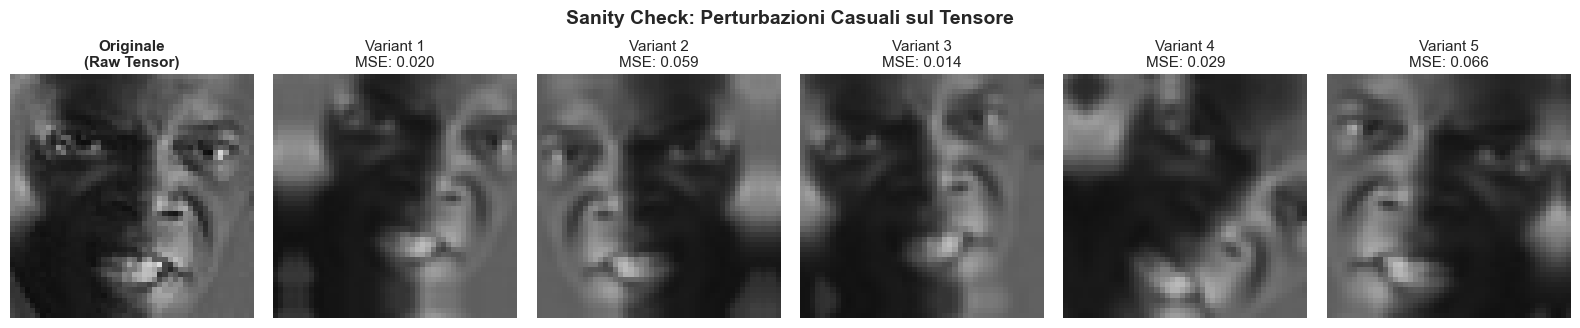

In [5]:
def _plot_augmentation_results(img_raw_sq: np.ndarray, augmented_data: List[Dict[str, Any]]) -> None:
    """Funzione helper per il rendering grafico del Sanity Check."""
    num_samples = len(augmented_data)
    fig, axes = plt.subplots(1, num_samples + 1, figsize=(16, 3.5))
    fig.suptitle("Sanity Check: Perturbazioni Casuali sul Tensore", fontsize=14, fontweight='bold')
    
    # Render dell'immagine Originale (Scala 0-255)
    axes[0].imshow(img_raw_sq, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title("Originale\n(Raw Tensor)", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Render delle varianti aumentate (Scala 0.0-1.0 dovuta al Rescaling)
    for i, data in enumerate(augmented_data):
        ax = axes[i + 1]
        ax.imshow(data['image'], cmap='gray', vmin=0.0, vmax=1.0)
        ax.set_title(f"Variant {i+1}\nMSE: {data['mse']:.3f}", fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('sanity_check_augmentation.svg', format='svg', bbox_inches='tight')
    plt.show()

def evaluate_augmentation_mathematically(dataset: tf.data.Dataset, aug_model: tf.keras.Sequential, num_samples: int = 5) -> None:
    """
    Estrae un'immagine reale e ne valuta matematicamente la trasformazione spaziale.
    """
    # 1. Estrazione deterministica del primo campione
    images, labels = next(iter(dataset.take(1)))
    img_raw = images[0]
    label = labels[0].numpy()
    
    # 2. Normalizzazione baseline per il calcolo del delta
    img_norm = img_raw / 255.0
    
    print(f"--- ANALISI TENSORIALE (Campione estratto: Classe {label}) ---")
    print(f"Stato Raw  -> Min: {tf.reduce_min(img_raw):.1f} | Max: {tf.reduce_max(img_raw):.1f}")
    print(f"Stato Norm -> Media: {tf.reduce_mean(img_norm):.4f} | Std: {tf.math.reduce_std(img_norm):.4f}\n")

    augmented_results = []
    
    # 3. Generazione varianti statistiche
    for i in range(num_samples):
        # Passiamo il tensore espanso [Batch, H, W, C] attraverso l'augmentation
        aug_batch = aug_model(tf.expand_dims(img_raw, 0), training=True)
        aug_img = aug_batch[0] 
        
        # Estrazione delle metriche matematiche
        aug_mean = tf.reduce_mean(aug_img)
        aug_std = tf.math.reduce_std(aug_img)
        mse = tf.reduce_mean(tf.square(img_norm - aug_img))
        
        print(f"Variant {i+1:<2} -> Media: {aug_mean:.4f} | Contrasto (Std): {aug_std:.4f} | Distorsione (MSE): {mse:.4f}")
        
        augmented_results.append({
            'image': tf.squeeze(aug_img).numpy(),
            'mse': mse
        })

    # Rendering
    _plot_augmentation_results(tf.squeeze(img_raw).numpy(), augmented_results)

evaluate_augmentation_mathematically(train_ds, data_augmentation)

## Conclusioni della Fase 2
Le operazioni strutturate in questa pipeline neutralizzano i bias emersi durante la Fase 1:

1. **Gestione Algoritmica dello Sbilanciamento:** La classe *Disgust* è stata dotata di un moltiplicatore di Loss severo ($\approx 9.41$). La rete, durante l'addestramento, sarà obbligata ad aggiornare drasticamente i propri pesi ogni volta che fallirà nel riconoscere questa classe rara. 
2. **Integrità Normalizzata:** L'output del Sanity Check conferma che il layer di `Rescaling` comprime con successo il range dei pixel in un formato a virgola mobile $\in [0, 1]$, neutralizzando gli abbagli luminosi.
3. **Stabilità Spaziale:** Le misurazioni dell'Errore Quadratico Medio (MSE) prodotte dal blocco di Augmentation fluttuano in un *safe range* tipico ($\approx 0.01 - 0.06$). Questo certifica che le rotazioni e gli zoom inseriscono il giusto grado di incertezza spaziale senza sconfinare nella corruzione irriconoscibile dell'immagine.

L'infrastruttura *ETL (Extract, Transform, Load)* è ora formalmente testata. Nel prossimo notebook implementeremo la Baseline tramite Machine Learning lineare.